# TPOSE24 Domain-mean Velocity

Time- and depth-averaged U, V, W over the full model domain (Oct 11 – Dec 2012, 0–70 m).

In [1]:
import numpy as np
import sys
sys.path.insert(0, '/home/edavenport/analysis/tpose24-osse')
from osse_tools import load_model
import matplotlib.pyplot as plt
import cmocean.cm as cmo

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## Configuration

In [36]:
RUN_DIR  = '/data/SO3/edavenport/tpose24/oct2012_3month_transp_cons'
ITERS    = list(range(36, 26173, 36))
MAX_DEPTH = 250  # metres

## Load model

In [37]:
ds = load_model(RUN_DIR, ITERS)
ds = ds.sel(time=slice('2012-10-11', '2012-11-11'))

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

## Compute time- and depth-mean

In [38]:
u_mean = ds.UVEL.where(ds.Z  >= -MAX_DEPTH).mean(['time', 'Z']).compute()
v_mean = ds.VVEL.where(ds.Z  >= -MAX_DEPTH).mean(['time', 'Z']).compute()
w_mean = ds.WVEL.where(ds.Zl >= -MAX_DEPTH).mean(['time', 'Zl']).compute()
print('Done')

Done


## Plot

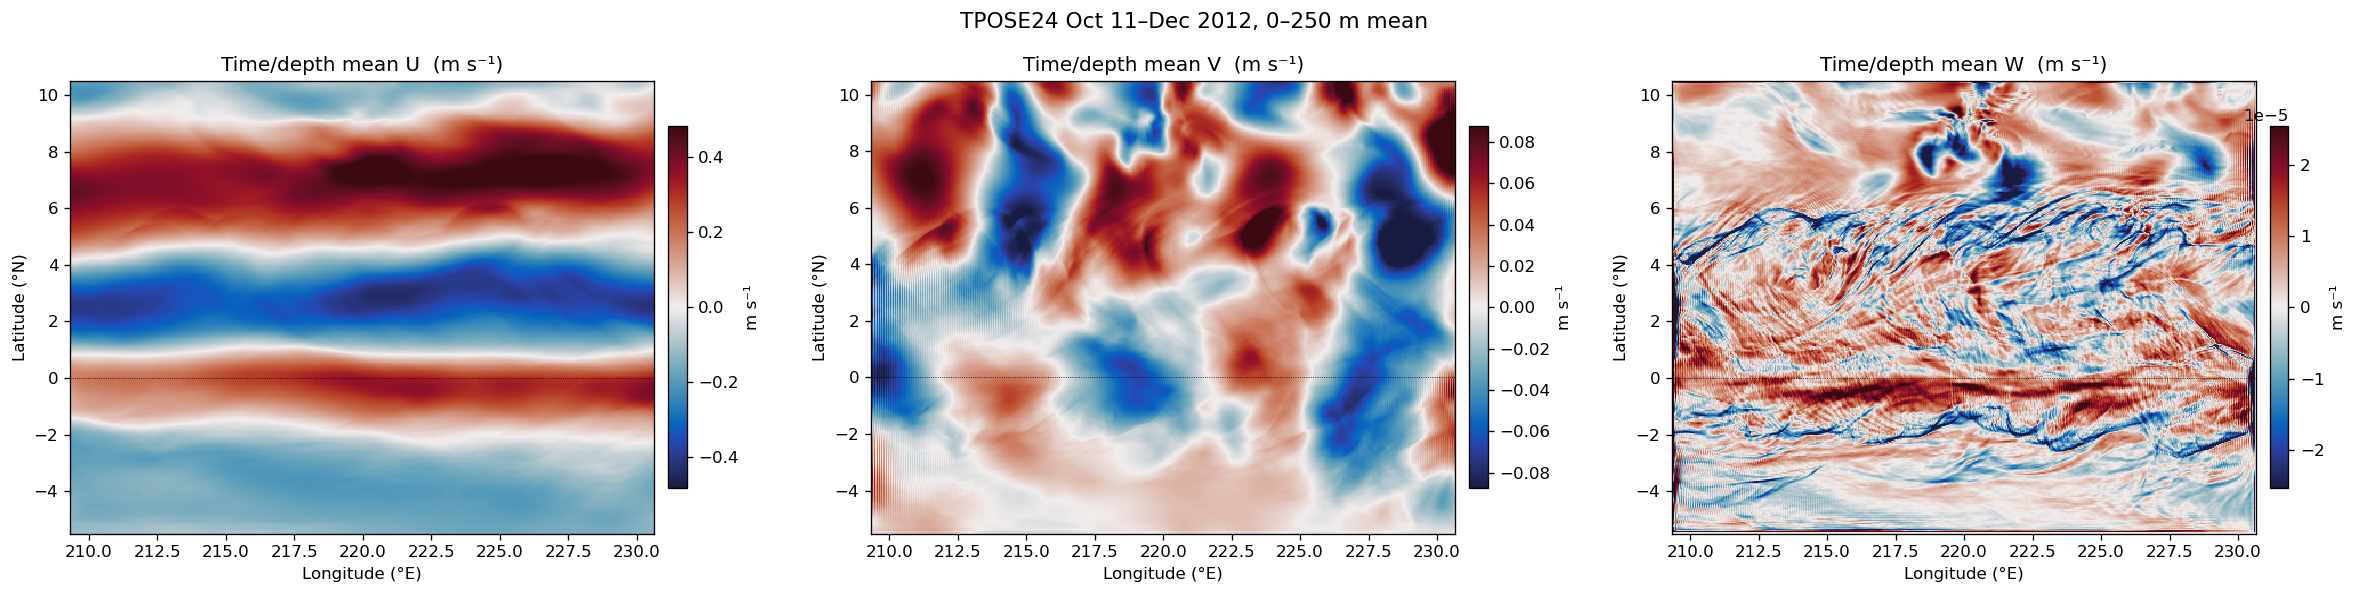

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

panels = [
    (u_mean, ds.XG.values, ds.YC.values, 'Time/depth mean U  (m s\u207b\u00b9)'),
    (v_mean, ds.XC.values, ds.YG.values, 'Time/depth mean V  (m s\u207b\u00b9)'),
    (w_mean, ds.XC.values, ds.YC.values, 'Time/depth mean W  (m s\u207b\u00b9)'),
]

for ax, (data, xx, yy, title) in zip(axes, panels):
    vmax = float(np.nanpercentile(np.abs(data.values), 98))
    im = ax.pcolormesh(xx, yy, data.values, cmap=cmo.balance,
                       vmin=-vmax, vmax=vmax, shading='auto')
    plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02, label='m s\u207b\u00b9')
    ax.axhline(0, color='k', lw=0.5, ls=':')
    ax.set_xlabel('Longitude (\u00b0E)')
    ax.set_ylabel('Latitude (\u00b0N)')
    ax.set_title(title)

fig.suptitle(f'TPOSE24 Oct 11\u2013Dec 2012, 0\u2013{MAX_DEPTH} m mean', fontsize=13)
fig.tight_layout()
plt.savefig(f'domain_mean_velocity_{MAX_DEPTH}m_1mo.png', dpi=150, bbox_inches='tight')
plt.show()

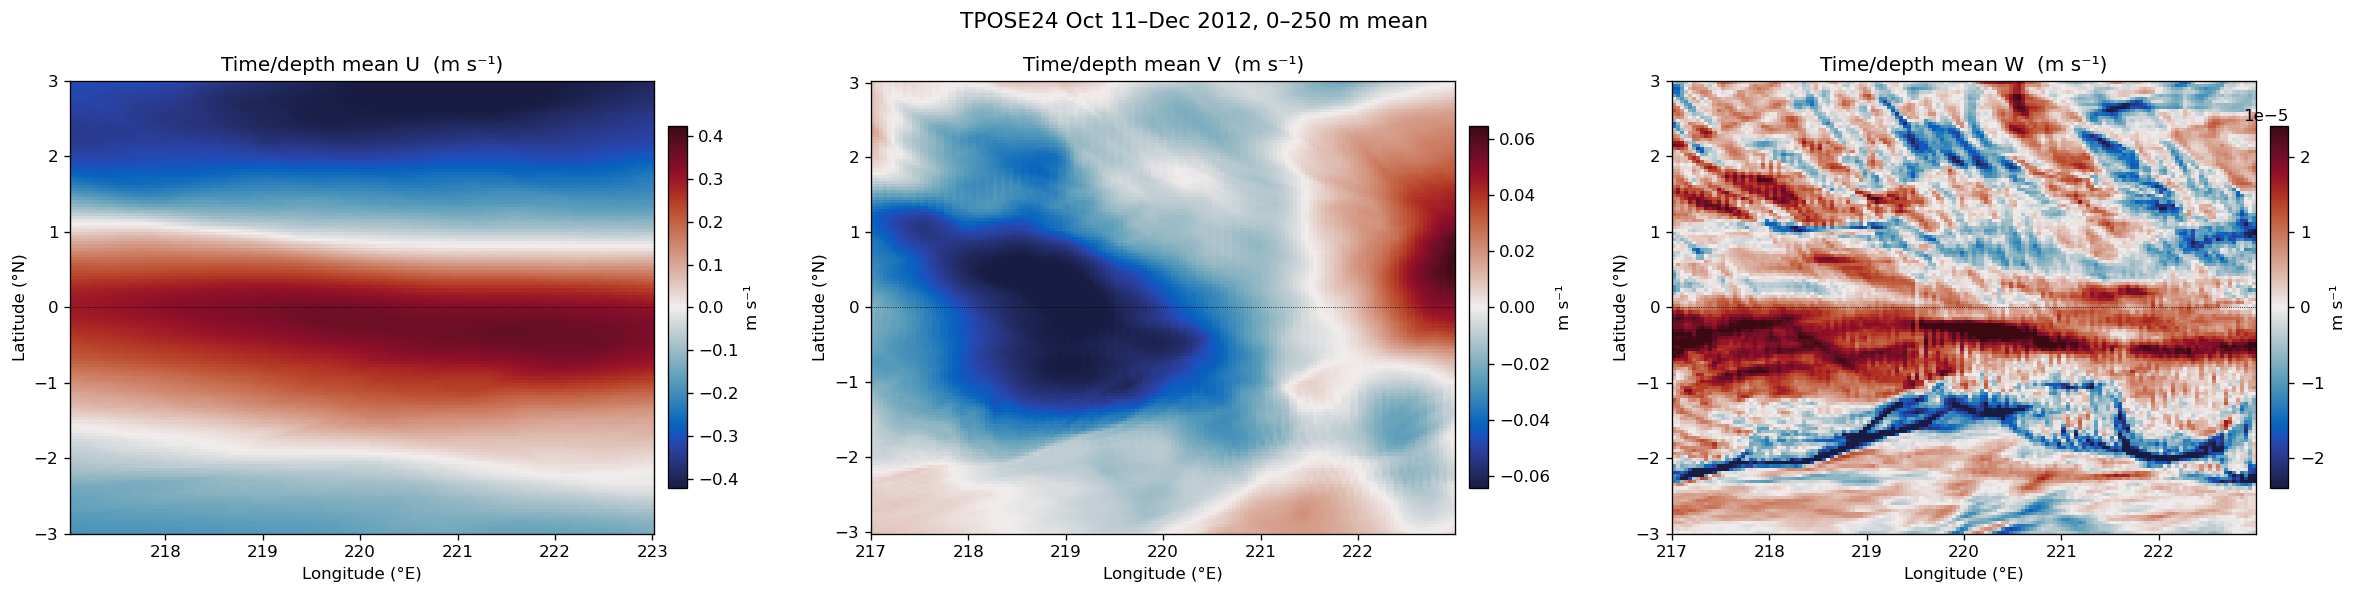

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
ucrop = u_mean.sel(XG=slice(217,223), YC=slice(-3,3))
vcrop = v_mean.sel(XC=slice(217,223), YG=slice(-3,3))
wcrop = w_mean.sel(XC=slice(217,223), YC=slice(-3,3))

panels = [
    (ucrop, ucrop.XG.values, ucrop.YC.values, 'Time/depth mean U  (m s\u207b\u00b9)'),
    (vcrop, vcrop.XC.values, vcrop.YG.values, 'Time/depth mean V  (m s\u207b\u00b9)'),
    (wcrop, wcrop.XC.values, wcrop.YC.values, 'Time/depth mean W  (m s\u207b\u00b9)'),
]

for ax, (data, xx, yy, title) in zip(axes, panels):
    vmax = float(np.nanpercentile(np.abs(data.values), 98))
    im = ax.pcolormesh(xx, yy, data.values, cmap=cmo.balance,
                       vmin=-vmax, vmax=vmax, shading='auto')
    plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02, label='m s\u207b\u00b9')
    ax.axhline(0, color='k', lw=0.5, ls=':')
    ax.set_xlabel('Longitude (\u00b0E)')
    ax.set_ylabel('Latitude (\u00b0N)')
    ax.set_title(title)

fig.suptitle(f'TPOSE24 Oct 11\u2013Dec 2012, 0\u2013{MAX_DEPTH} m mean', fontsize=13)
fig.tight_layout()
plt.savefig(f'crop_domain_mean_velocity_{MAX_DEPTH}m_1mo.png', dpi=150, bbox_inches='tight')
plt.show()